<a href="https://colab.research.google.com/github/akuntugasrapon/RafkiAhmadPagamanda_2311533016_ML2526/blob/main/Praktikum1/Single_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LATIHAN 2

STEP 1 — Import Library

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

STEP 2 — Mount Google Drive

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
DATA_PATH = "/content/drive/MyDrive/ML/Dataset/advertising.csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()
df.describe()

(200, 4)


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


STEP 3 — Visualisasi

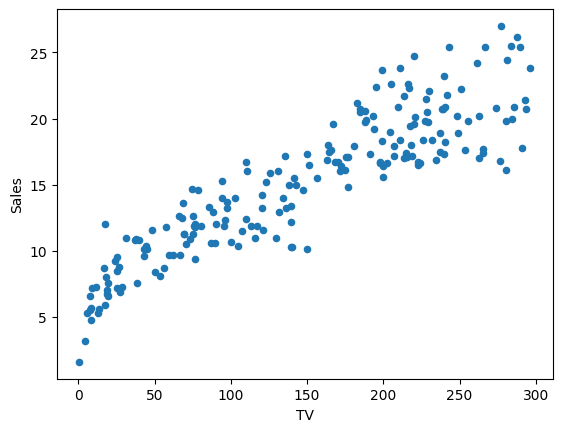

In [24]:
df.plot(kind='scatter', x='TV', y='Sales')
plt.show()

STEP 4 — Pisahkan Variabel

In [25]:
X = df[['TV']]
y = df[['Sales']]

reg_model = LinearRegression().fit(X, y)

print("Intercept:", reg_model.intercept_)
print("Coefficient:", reg_model.coef_)

Intercept: [6.97482149]
Coefficient: [[0.05546477]]


STEP 5 — Prediksi TV=150 & 500

In [26]:
tv_150 = reg_model.predict([[150]])
tv_500 = reg_model.predict([[500]])

print("TV 150:", tv_150)
print("TV 500:", tv_500)

TV 150: [[15.29453706]]
TV 500: [[34.70720672]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


STEP 6 — Visualisasi Garis Regresi

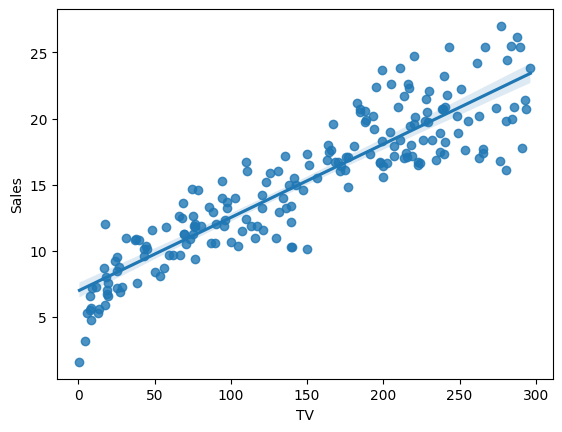

In [27]:
sns.regplot(x='TV', y='Sales', data=df)
plt.show()

LATIHAN 3 – MULTIPLE LINEAR REGRESSION

1. Pisahkan Variabel

In [28]:
X_multi = df[['TV', 'Radio', 'Newspaper']]
y_multi = df['Sales']

2. Split Data (70% Training, 30% Testing)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.3,
    random_state=42
)

3. Latih Model Multiple Linear Regression

In [30]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print("Intercept:", model_multi.intercept_)
print("Koefisien:")
for fitur, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"{fitur}: {coef}")

Intercept: 4.743766701589685
Koefisien:
TV: 0.05358869132706914
Radio: 0.10270676778771287
Newspaper: 0.007931667677316324


4. Prediksi Data Baru

In [31]:
data_baru = pd.DataFrame([[30,1,40]],
                         columns=['TV','Radio','Newspaper'])

prediksi = model_multi.predict(data_baru)

print("Prediksi Sales:", prediksi[0])

Prediksi Sales: 6.771400916282126


5. Evaluasi Model

In [32]:
y_pred = model_multi.predict(X_test)

MSE

In [33]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2.541624036229147


RMSE

In [34]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 1.5942471691143587


MAE

In [35]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.1594875061090582


R²

In [36]:
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

R2: 0.9091484341849799


Visualisasi Prediksi vs Aktual:

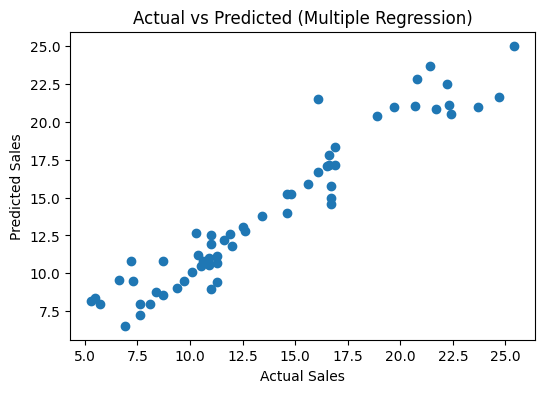

In [37]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Multiple Regression)")
plt.show()